In [1]:
import torch
import os, sys
import numpy as np
import matplotlib.pyplot as plt

In [2]:
project_path = os.path.dirname(os.getcwd())
print(project_path)
sys.path.append(project_path)

import radar_sim.config as config 
from radar_sim.transmitter import PulseRadar, CWRadar

c:\Users\denisa.qosja\Documents\Projects\SignalProcessing-NN


In [3]:
%load_ext autoreload
%autoreload 2

In [7]:
# def pulse_signal(f0, t, phase=0):
#     x_complex = torch.exp(2j* np.pi * f0 * t + phase)
#     return x_complex

def chirp(amplitude, bandwidth, pulse_width, t, f0=0, phase=0):
    #t = torch.from_numpy(t)
    k = bandwidth / pulse_width                                  # chirp slope = rate of change of frequency
    f_linear_chirp = f0 + (k/2)*t                                # instantaneous frequency of the chirp signal
    chirp = amplitude * torch.exp(2j* np.pi*f_linear_chirp*t + phase)
    return chirp 

pulse_radar = PulseRadar(config.GLOBAL_PARAMETERS, config.TX_PARAMETERS)
amplitude = 1


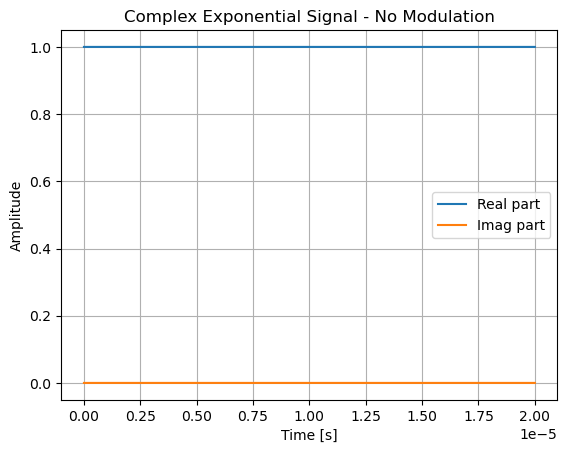

In [8]:
pulse = pulse_radar.pulse_signal(pulse_radar.tx_parameters["amplitude"], pulse_radar.t)

plt.plot(pulse_radar.t, np.real(pulse), label='Real part')
plt.plot(pulse_radar.t, np.imag(pulse), label='Imag part')
plt.title("Complex Exponential Signal - No Modulation")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()


# --- a simpler baseband signal for testing purposes ---

# Parameters
# A = 1          # amplitude
# f0 = 5         # frequency in Hz
# phi = 0        # phase
# T = 1          # duration in seconds
# Fs = 100       # sampling rate in Hz

# t_ = np.arange(0, T, 1/Fs)

# x_ = A * np.exp(2j * np.pi * f0 * t_ + phi)
# print(x_.dtype)
# plt.title("Baseband Signal")
# plt.plot(t_, np.real(x_), label='Real part')
# plt.plot(t_, np.imag(x_), label='Imag part')
# plt.xlabel("Time [s]")
# plt.ylabel("Amplitude")
# plt.grid(True)
# plt.show()

### Chirp

4800


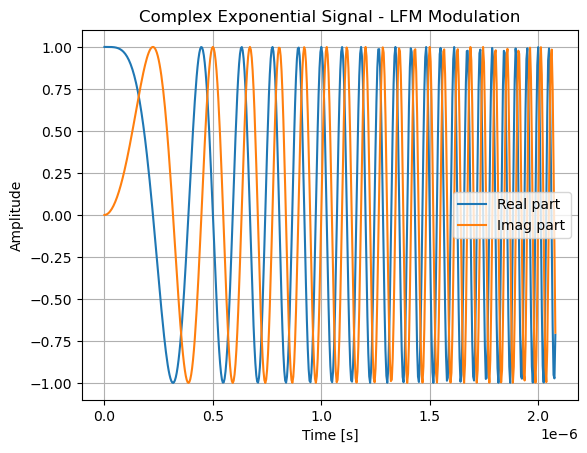

In [9]:
end = 500
chirp_signal = pulse_radar.chirp(amplitude, pulse_radar.bandwidth, pulse_radar.pulse_width, pulse_radar.t)
print(len(chirp_signal))
plt.plot(pulse_radar.t[:end], np.real(chirp_signal[:end]), label='Real part')
plt.plot(pulse_radar.t[:end], np.imag(chirp_signal[:end]), label='Imag part')

plt.title("Complex Exponential Signal - LFM Modulation")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

Chirp slope (k): 10000000000000.0 Hz/s


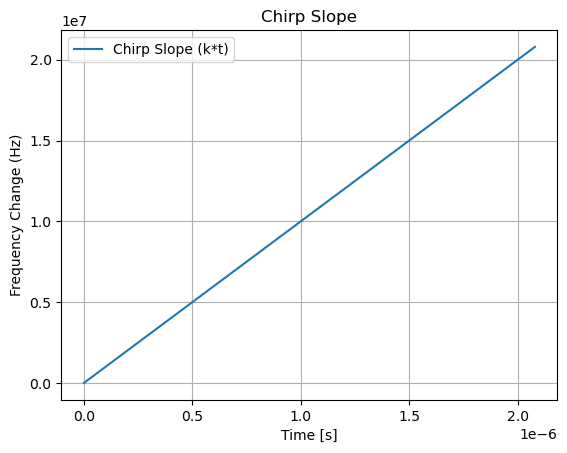

In [10]:
# rate of change of chirp frequency
k = pulse_radar.bandwidth / pulse_radar.pulse_width
print(f"Chirp slope (k): {k} Hz/s") 
plt.plot(pulse_radar.t[:end], k*pulse_radar.t[:end], label='Chirp Slope (k*t)')
plt.title("Chirp Slope")   
plt.xlabel("Time [s]")
plt.ylabel("Frequency Change (Hz)") 
plt.legend()
plt.grid(True)      
plt.show() 

In [22]:
def create_pulse_train(fs, single_pulse_signal, n_samples_tao, n_pulses=1):
    """
    Append the generated pulse signal to create a pulse train,
    based on the number of pulses and the pulse repetition frequency (prf)
    
    :param self: Description
    :param tx_signal: Description
    """
    prf = 2000
    print(f"{fs = }")
    # create the full PRI (pulse repetition interval) time vector for the pulse train
    n_samples_pri = int(fs * (1 / prf))  # number of samples in one PRI
    t_pri = torch.linspace(start=0, end=(1 / prf), steps=int(n_samples_pri))

    pulse_signal_pri = torch.zeros(n_samples_pri, dtype=torch.complex64)
    pulse_signal_pri[:n_samples_tao] = single_pulse_signal
    print(f"{len(single_pulse_signal) = } ")
    print(f"{len(pulse_signal_pri) = } ")
    
    # repeat the pulse signal for n_pulses to create the pulse train
    # pulse_train = pulse_signal_pri.repeat(self.tx_parameters["pulse"]["n_pulses"])
    pulse_train = pulse_signal_pri.repeat(n_pulses)
    return pulse_train, t_pri, n_samples_pri
    

pulse_train, t_pri, n_samples_pri = create_pulse_train(pulse_radar.fs, 
                                               chirp_signal, 
                                               pulse_radar.n_samples, 
                                               n_pulses=pulse_radar.tx_parameters["pulse"]["n_pulses"])
duty_cycle = pulse_radar.pulse_width * pulse_radar.prf
print(duty_cycle)     

fs = 240000000.0
len(single_pulse_signal) = 4800 
len(pulse_signal_pri) = 120000 
0.04


In [ ]:
print(n_samples_pri, len(t_pri))

In [ ]:
num_samples_pulse_train = n_samples_pri * pulse_radar.tx_parameters["pulse"]["n_pulses"]
# continuous time across full pulse train
t_pulse_train = torch.arange(num_samples_pulse_train) / pulse_radar.fs 
len(num_samples_pulse_train, t_pulse_train)

15360000


15360000

In [20]:
print(len(pulse_train))
print(pulse_radar.tx_parameters["pulse"]["n_pulses"])
print(n_samples_pri)

15360000
128
120000


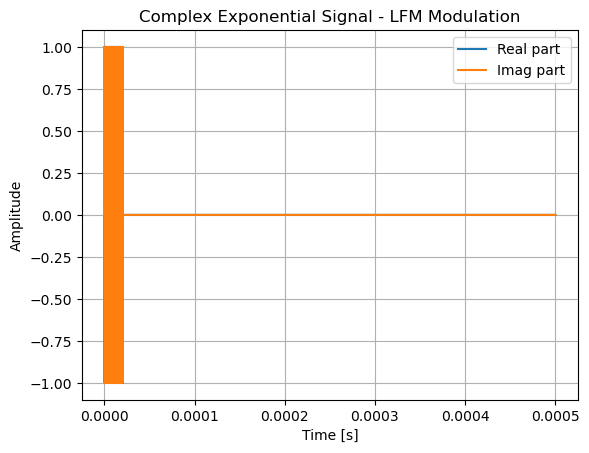

In [21]:
end = n_samples_pri
chirp_signal = pulse_radar.chirp(amplitude, pulse_radar.bandwidth, pulse_radar.pulse_width, pulse_radar.t)
plt.plot(t_pri, np.real(pulse_train[:end]), label='Real part')
plt.plot(t_pri, np.imag(pulse_train[:end]), label='Imag part')

plt.title("Complex Exponential Signal - LFM Modulation")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()